# Local Group analogues (modular)

This notebook demonstrates a reusable workflow:

1. Load TNG group catalog fields
2. Select **central + largest satellite** (by stellar mass) in a stellar-mass window
3. Find candidate pairs in a distance window with periodic boundaries
4. Apply an isolation filter
5. Plot basic diagnostics


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import h5py


from lg_analogues import (
    load_header_constants,
    select_central_plus_largest_satellite_by_stellar_mass,
    find_pairs_periodic,
    isolation_filter_no_third_factor_x_in_same_group,
)

basePath = os.path.abspath("../tng300/outputs/")
snap = 99


In [2]:
# Load header constants (h and box size)
const = load_header_constants(basePath, snap)
h = const["h"]
box = const["box_ckpch"]

print("h:", h)
print("BoxSize [ckpc/h]:", box)


h: 0.6774
BoxSize [ckpc/h]: 205000.0


In [3]:
# Load subhalo fields needed for selection and pair finding
subhalo_fields = [ 
    "SubhaloPos",       # Spatial position within the periodic box (of the particle with the minium gravitational potential energy). Comoving coordinate. Units: ckpc/h 
    "SubhaloVel",       # Peculiar velocity of the group, computed as the sum of the mass weighted velocities of all particles/cells in this group, of all types. No unit conversion is needed. Units: km/s
    "SubhaloMass",      # Total mass of all member particle/cells which are bound to this Subhalo, of all types. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloMassType",  # Total mass of all member particle/cells which are bound to this Subhalo, separated by type. Particle/cells bound to subhaloes of this Subhalo are NOT accounted for. Units: 1e10 Msun/h
    "SubhaloSFRinRad",  # Sum of the individual star formation rates of all gas cells in this subhalo, but restricted to cells within the radius of 𝑉𝑚𝑎𝑥. Units Msun/yr
    "SubhaloFlag",      # Flag field indicating suitability of this subhalo for certain types of analysis. If zero, this subhalo should generally be excluded, and is not thought to be of cosmological origin.
    "SubhaloGrNr"       # Index into the Group table of the FOF host/parent of this Subhalo. 
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
print("All subhalos:", sub["count"])


All subhalos: 14485709


In [4]:
# Selection: centrals with stellar mass in window, plus largest satellite in window (per FoF group)
mstar_min = 2e10
mstar_max = 5e11

sample = select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=mstar_min,
    mstar_max=mstar_max,
)

print("Sample size:", sample.pos.shape[0])
print("Stellar mass range [Msun]:", float(sample.mstar.min()), float(sample.mstar.max()))
print("Groups represented:", np.unique(sample.grnr).size)


Sample size: 45392
Stellar mass range [Msun]: 20000320076.4145 499936405944.3737
Groups represented: 38778


In [5]:
# Load supplementary data catalog (c) from https://www.tng-project.org/data/docs/specifications/#sec5c using h5py
from typing import Dict, List
import numpy as np

def get_catalog_fields_with_sample_ids(
    path: str, 
    snapshot: str, 
    sample_ids: np.ndarray, 
    fields: List[str]
) -> Dict[str, np.ndarray]:
    """Extract catalog fields for a subset of sample IDs.
    
    Reads multiple datasets from an HDF5 catalog file and matches them to sample IDs
    using a dictionary lookup. Fields are only returned for IDs present in the catalog;
    missing IDs are filled with np.nan.
    
    Args:
        path: Absolute path to the HDF5 catalog file (e.g., 'stellar_circs.hdf5').
        snapshot: Group name within the HDF5 file (e.g., 'Snapshot_99').
        sample_ids: Array of subhalo IDs to extract values for (length M_sample).
        fields: List of dataset names to load from the catalog snapshot.
    
    Returns:
        Dictionary mapping field names to numpy arrays of length len(sample_ids).
        Each array is aligned to sample_ids order; missing values are np.nan.
    
    Example:
        >>> result = get_catalog_fields_with_sample_ids(
        ...     path='../tng300/catalog_c/stellar_circs.hdf5',
        ...     snapshot='Snapshot_99',
        ...     sample_ids=sample.keep_idx,
        ...     fields=['CircAbove07Frac', 'SpecificAngMom']
        ... )
        >>> circ_values = result['CircAbove07Frac']  # length == len(sample.keep_idx)
    """
    catalog_dict: Dict[str, np.ndarray] = {}
    
    with h5py.File(path, "r") as f:
        snap = f[snapshot]
        
        # Load the catalog's subhalo ID array (index into catalog)
        catalog_ids = snap["SubfindID"][...].astype(int)   # length N_catalog
        
        for field in fields:
            # Load the field values from catalog (same length as catalog_ids)
            catalog_vals = snap[field][...]  # length N_catalog
            
            # Build ID → value mapping for fast lookup
            id_to_val = dict(zip(catalog_ids, catalog_vals))
            
            # Extract values for sample_ids; use np.nan for missing IDs
            catalog_dict[field] = np.array(
                [id_to_val.get(sid, np.nan) for sid in sample_ids],
                dtype=catalog_vals.dtype
            )
    
    return catalog_dict


# Load catalog fields for the selected sample
path = os.path.abspath("../tng300/catalog_c/stellar_circs.hdf5")
snapshot = "Snapshot_99"
fields = [
    "CircAbove07Frac",
    "CircAbove07Frac_allstars",
    "CircAbove07MinusBelowNeg07Frac",
    "CircAbove07MinusBelowNeg07Frac_allstars",
    "CircTwiceBelow0Frac",
    "CircTwiceBelow0Frac_allstars",
    "MassTensorEigenVals",
    "ReducedMassTensorEigenVals",
    "SpecificAngMom",
    "SpecificAngMom_allstars",
]

# Execute the function and display a sample result
catalog_data = get_catalog_fields_with_sample_ids(path, snapshot, sample.keep_idx, fields)
print("Catalog fields loaded successfully.")
print(f"Sample size: {len(sample.keep_idx)}")
print(f"Fields: {list(catalog_data.keys())}")
print(f"\nSpecificAngMom (first 10 values):\n{catalog_data['SpecificAngMom'][:10]}")
print()

Catalog fields loaded successfully.
Sample size: 45392
Fields: ['CircAbove07Frac', 'CircAbove07Frac_allstars', 'CircAbove07MinusBelowNeg07Frac', 'CircAbove07MinusBelowNeg07Frac_allstars', 'CircTwiceBelow0Frac', 'CircTwiceBelow0Frac_allstars', 'MassTensorEigenVals', 'ReducedMassTensorEigenVals', 'SpecificAngMom', 'SpecificAngMom_allstars']

SpecificAngMom (first 10 values):
[ 3219.1362    372.83414 55537.92     2191.8503   4440.376    2590.6619
  3466.8015    738.4634   3143.3005   2573.9292 ]



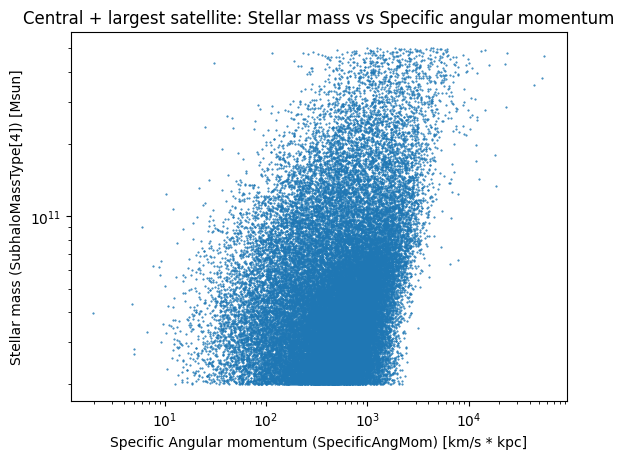

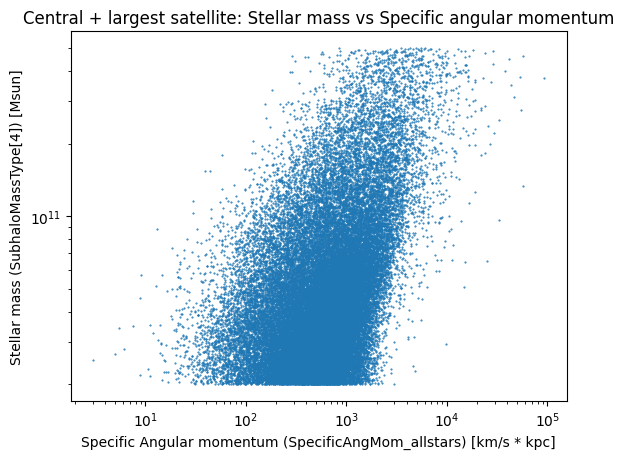

In [6]:
# SpecificAngMom against mass
# SubhaloMassType units are 1e10 Msun/h
mstar = sample.mtype[:, 4].astype(np.float64) * 1e10 / h

plt.figure()
plt.plot(catalog_data['SpecificAngMom'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Specific Angular momentum (SpecificAngMom) [km/s * kpc]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Specific angular momentum")
plt.show()

# Allstars 
# Fields are also computed including all stars in the subhalo. These are available as the _allstars datasets
plt.figure()
plt.plot(catalog_data['SpecificAngMom_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Specific Angular momentum (SpecificAngMom_allstars) [km/s * kpc]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Specific angular momentum")
plt.show()

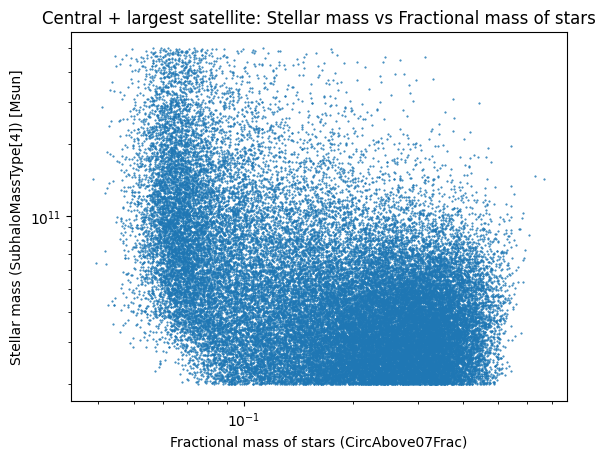

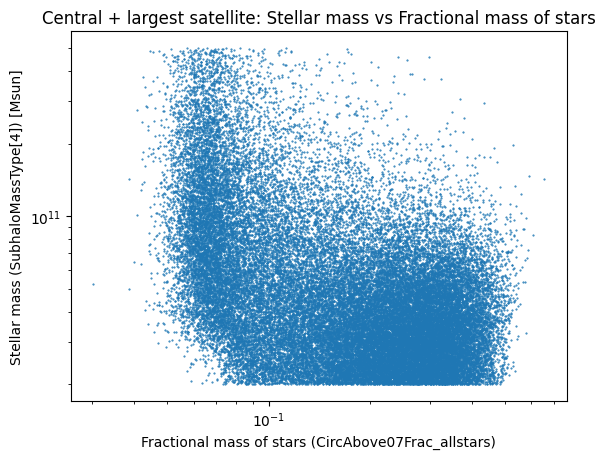

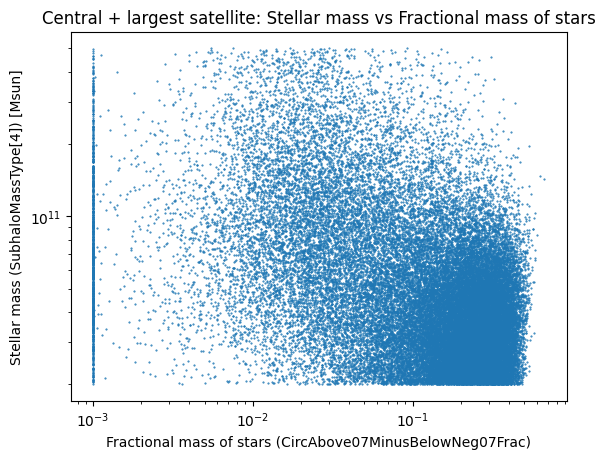

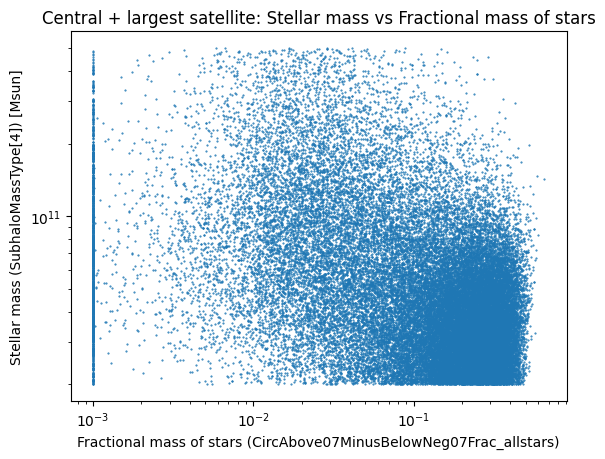

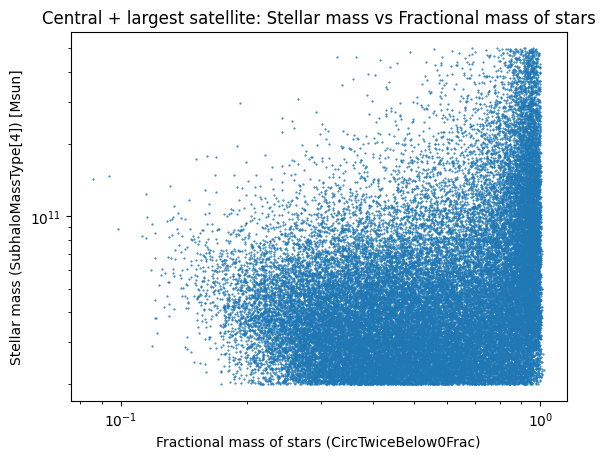

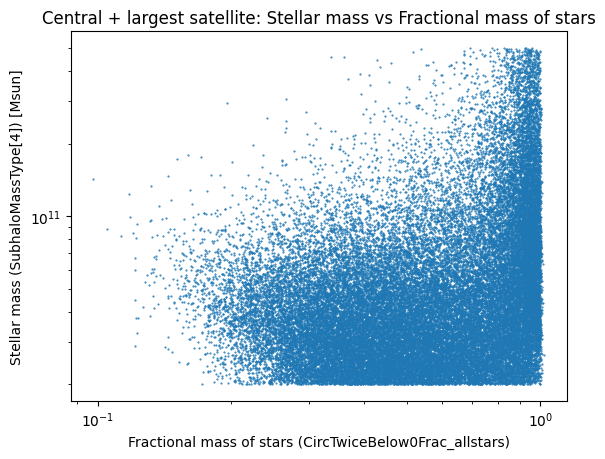

In [7]:
# Fractional mass of stars against total subhalo stellar mass

# CircAbove07Frac
plt.figure()
plt.plot(catalog_data['CircAbove07Frac'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07Frac)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircAbove07Frac_allstars
plt.figure()
plt.plot(catalog_data['CircAbove07Frac_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07Frac_allstars)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircAbove07MinusBelowNeg07Frac
plt.figure()
plt.plot(catalog_data['CircAbove07MinusBelowNeg07Frac'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07MinusBelowNeg07Frac)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircAbove07MinusBelowNeg07Frac_allstars
plt.figure()
plt.plot(catalog_data['CircAbove07MinusBelowNeg07Frac_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07MinusBelowNeg07Frac_allstars)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()


# CircTwiceBelow0Frac
plt.figure()
plt.plot(catalog_data['CircTwiceBelow0Frac'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircTwiceBelow0Frac)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircTwiceBelow0Frac_allstars
plt.figure()
plt.plot(catalog_data['CircTwiceBelow0Frac_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircTwiceBelow0Frac_allstars)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

In [8]:
# Pair finding (periodic), 500–1000 kpc
pairs = find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box,
    r_min_kpc=500.0,
    r_max_kpc=1000.0,
)

print("Pairs:", pairs.i.size)
print("Same-host pairs:", int(pairs.same_host.sum()))
print("Different-host pairs:", int((~pairs.same_host).sum()))


Pairs: 2655
Same-host pairs: 2084
Different-host pairs: 571


In [9]:
print(sample.keep_idx[np.max(pairs.i)])
print(sample.keep_idx)

2174190
[ 254681  254683  268726 ... 2377689 2386229 2396060]


In [10]:

catalog_data = get_catalog_fields_with_sample_ids(path, snapshot, sample.keep_idx[np.concatenate([pairs.i, pairs.j])], fields)

In [11]:
print(catalog_data['MassTensorEigenVals'])

[[ 4.6567383  5.4741063  6.1661205]
 [ 2.9898899  4.1808443  4.3242455]
 [11.727587  14.041683  20.729492 ]
 ...
 [ 1.7428546  3.1125278  3.3930619]
 [ 2.935611   3.7400937  3.8901556]
 [ 1.9701641  3.0233655  3.0733626]]


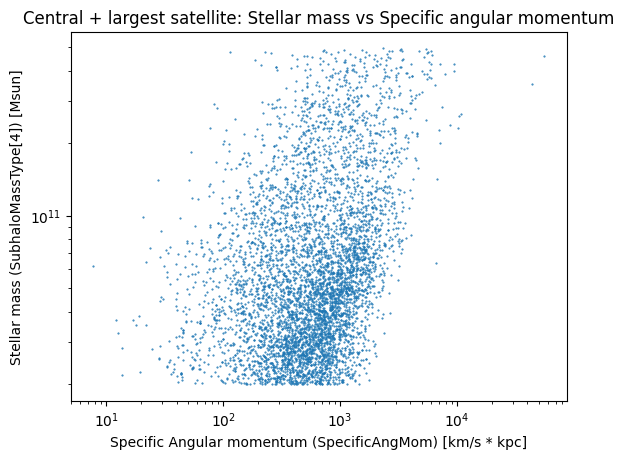

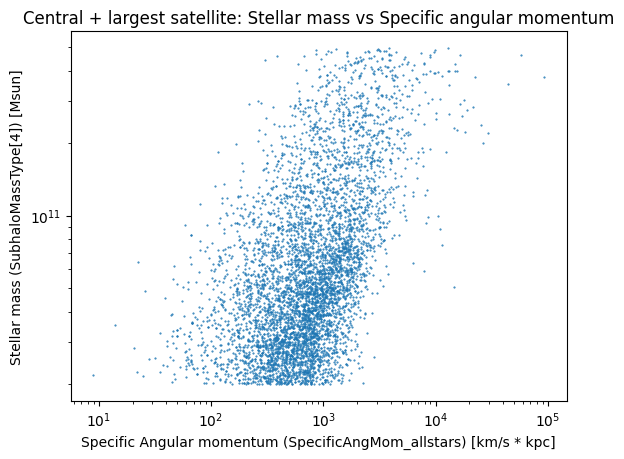

In [12]:
# SpecificAngMom against mass
# SubhaloMassType units are 1e10 Msun/h
mstar = sample.mtype[np.concatenate([pairs.i, pairs.j]), 4].astype(np.float64) * 1e10 / h

plt.figure()
plt.plot(catalog_data['SpecificAngMom'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Specific Angular momentum (SpecificAngMom) [km/s * kpc]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Specific angular momentum")
plt.show()

# Allstars 
# Fields are also computed including all stars in the subhalo. These are available as the _allstars datasets
plt.figure()
plt.plot(catalog_data['SpecificAngMom_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Specific Angular momentum (SpecificAngMom_allstars) [km/s * kpc]")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Specific angular momentum")
plt.show()

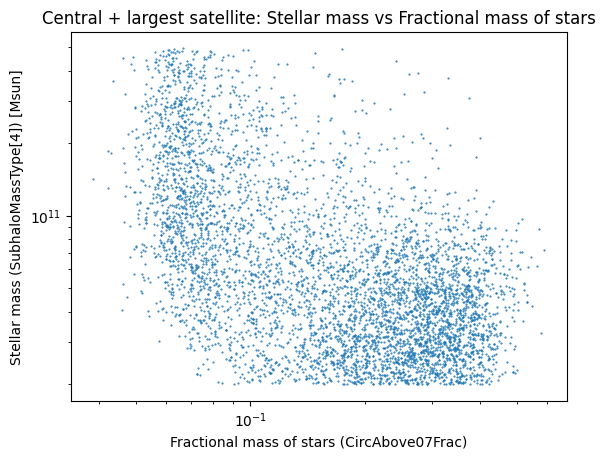

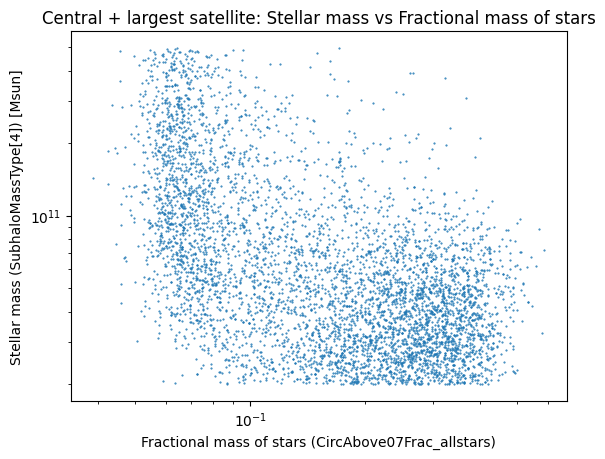

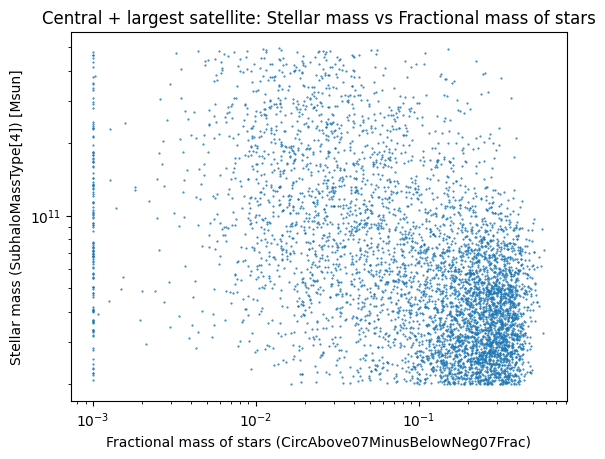

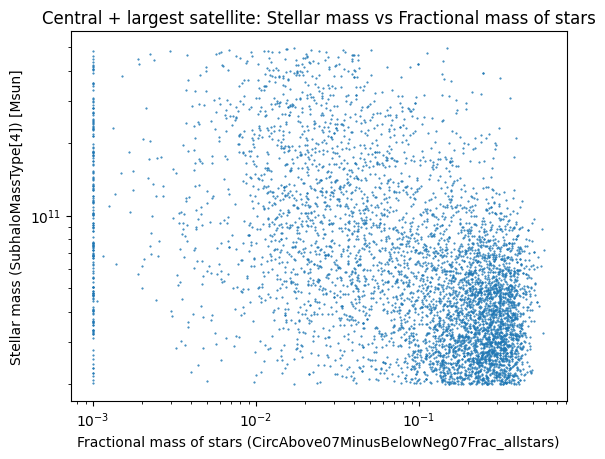

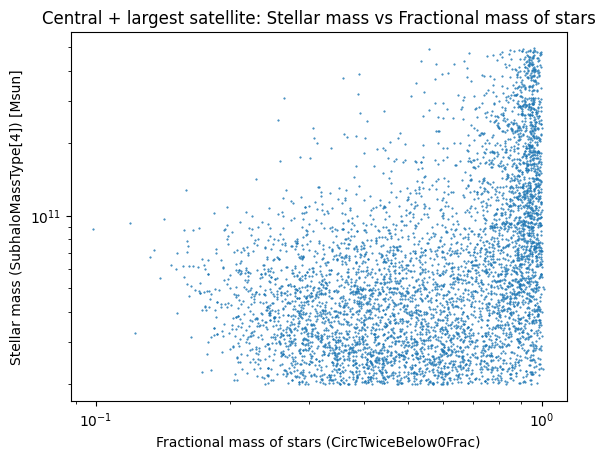

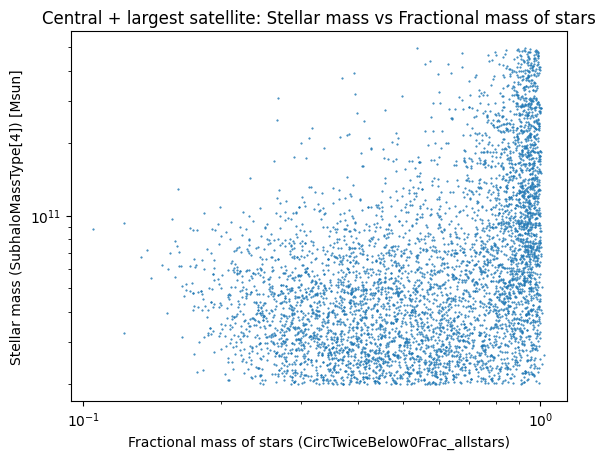

In [13]:
# Fractional mass of stars against total subhalo stellar mass

# CircAbove07Frac
plt.figure()
plt.plot(catalog_data['CircAbove07Frac'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07Frac)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircAbove07Frac_allstars
plt.figure()
plt.plot(catalog_data['CircAbove07Frac_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07Frac_allstars)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircAbove07MinusBelowNeg07Frac
plt.figure()
plt.plot(catalog_data['CircAbove07MinusBelowNeg07Frac'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07MinusBelowNeg07Frac)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircAbove07MinusBelowNeg07Frac_allstars
plt.figure()
plt.plot(catalog_data['CircAbove07MinusBelowNeg07Frac_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircAbove07MinusBelowNeg07Frac_allstars)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()


# CircTwiceBelow0Frac
plt.figure()
plt.plot(catalog_data['CircTwiceBelow0Frac'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircTwiceBelow0Frac)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

# CircTwiceBelow0Frac_allstars
plt.figure()
plt.plot(catalog_data['CircTwiceBelow0Frac_allstars'], mstar, ".", markersize=1.0)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fractional mass of stars (CircTwiceBelow0Frac_allstars)")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()

In [27]:
print(catalog_data['MassTensorEigenVals'])
print(catalog_data['MassTensorEigenVals'][:,0])
print(len(catalog_data['MassTensorEigenVals'][:,0]))

[[ 4.6567383  5.4741063  6.1661205]
 [ 2.9898899  4.1808443  4.3242455]
 [11.727587  14.041683  20.729492 ]
 ...
 [ 1.7428546  3.1125278  3.3930619]
 [ 2.935611   3.7400937  3.8901556]
 [ 1.9701641  3.0233655  3.0733626]]
[ 4.6567383  2.9898899 11.727587  ...  1.7428546  2.935611   1.9701641]
5310


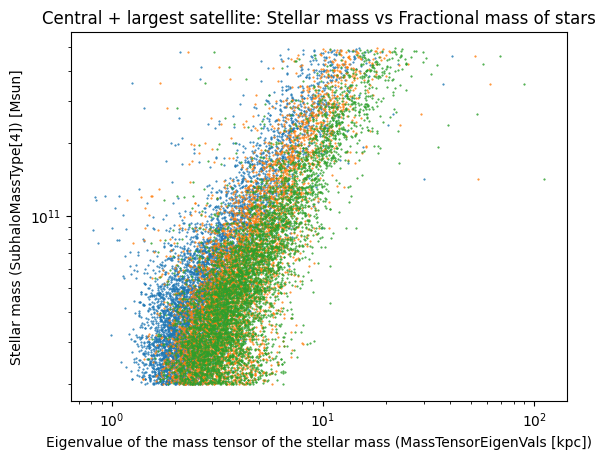

In [68]:
# Example plot utilizing catalog_data directly
# here we'll show a histogram of the first eigenvalue from MassTensorEigenVals

eig1 = catalog_data['MassTensorEigenVals'][:,0]
eig2 = catalog_data['MassTensorEigenVals'][:,1]
eig3 = catalog_data['MassTensorEigenVals'][:,2]

# MassTensorEigenVals 1
plt.figure()
plt.plot(catalog_data['MassTensorEigenVals'][:,0], mstar, ".", markersize=1.0, color="C0")
plt.plot(catalog_data['MassTensorEigenVals'][:,1], mstar, ".", markersize=1.0, color="C1")
plt.plot(catalog_data['MassTensorEigenVals'][:,2], mstar, ".", markersize=1.0, color="C2")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Eigenvalue of the mass tensor of the stellar mass (MassTensorEigenVals [kpc])")
plt.ylabel("Stellar mass (SubhaloMassType[4]) [Msun]")
plt.title("Central + largest satellite: Stellar mass vs Fractional mass of stars")
plt.show()
